# Download and Classify Images with Confidence Threshold

This notebook:
1. Downloads images from URLs in metadata CSV
2. Handles missing/unavailable images gracefully
3. Classifies images as Urban/Natural using ResNet
4. Filters by confidence threshold (only keeps high-confidence predictions)
5. Excludes Indoor predictions
6. Saves filtered dataset for training

## 1. Setup and Imports

In [ ]:
# MUST be first cell: set multiprocessing method for Windows
import torch.multiprocessing as mp
try:
    mp.set_start_method("spawn", force=True)
except RuntimeError:
    pass  # Already set

In [1]:
import os
import sys
from pathlib import Path

# Setup paths
current = Path.cwd()
src_path = current / "src" if (current / "src").exists() else current.parent
sys.path.insert(0, str(src_path))

from utils.paths import find_project_root

project_root = find_project_root(src_path)
data_dir = project_root / "data"
os.chdir(project_root)
sys.path.insert(0, str(project_root / "src"))
print("Project Root:", project_root)

Project Root: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS


In [2]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from pipelines.download_and_classify import (
    DownloadAndClassifyConfig,
    get_default_dataset_configs,
    select_dataset_configs,
    download_osv_mini_dataset,
    update_osv_mini_config,
    run_pipeline,
    save_results,
 )

c:\Users\camil\anaconda3\envs\tf\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

In [3]:
# ========== CONFIGURATION ==========

DATASET_MODE = "both"  # "mp16" | "osv_mini" | "both"
DOWNLOAD_OSV_MINI = False
VISUALIZE_DATASET = "both"  # "mp16" | "osv_mini" | "all" | "none"

# Default confidence threshold for all datasets
CONFIDENCE_THRESHOLD = 0.70  # Adjust this value (0.0 to 1.0)

# Per-dataset confidence thresholds (None means use default above)
# Only used when DATASET_MODE = "both"
CONFIDENCE_THRESHOLD_MP16 = 0.7  # e.g., 0.75
CONFIDENCE_THRESHOLD_OSV_MINI = 0.1  # e.g., 0.65

MAX_RETRIES = 2
TIMEOUT = 5
BATCH_SIZE = 128
NUM_DOWNLOAD_THREADS = 16
TEST_LIMIT = None

print(f"Dataset mode: {DATASET_MODE}")
print(f"Download osv_mini: {DOWNLOAD_OSV_MINI}")
print(f"Default Confidence Threshold: {CONFIDENCE_THRESHOLD}")
if DATASET_MODE == "both":
    print(f"  - mp16 threshold: {CONFIDENCE_THRESHOLD_MP16 or CONFIDENCE_THRESHOLD}")
    print(f"  - osv_mini threshold: {CONFIDENCE_THRESHOLD_OSV_MINI or CONFIDENCE_THRESHOLD}")
print(f"Parallel Downloads: {NUM_DOWNLOAD_THREADS} threads")
print(f"Batch Size: {BATCH_SIZE}")
if TEST_LIMIT:
    print(f"⚠️  TEST MODE: Processing only first {TEST_LIMIT} images")

Dataset mode: both
Download osv_mini: False
Default Confidence Threshold: 0.7
  - mp16 threshold: 0.7
  - osv_mini threshold: 0.1
Parallel Downloads: 16 threads
Batch Size: 128


In [4]:
dataset_configs = get_default_dataset_configs(project_root)

# Apply per-dataset confidence thresholds
if CONFIDENCE_THRESHOLD_MP16 is not None:
    dataset_configs["mp16"] = dataset_configs["mp16"].__class__(
        name=dataset_configs["mp16"].name,
        input_metadata=dataset_configs["mp16"].input_metadata,
        output_dir=dataset_configs["mp16"].output_dir,
        output_csv=dataset_configs["mp16"].output_csv,
        confidence_threshold=CONFIDENCE_THRESHOLD_MP16,
    )

if CONFIDENCE_THRESHOLD_OSV_MINI is not None:
    dataset_configs["osv_mini"] = dataset_configs["osv_mini"].__class__(
        name=dataset_configs["osv_mini"].name,
        input_metadata=dataset_configs["osv_mini"].input_metadata,
        output_dir=dataset_configs["osv_mini"].output_dir,
        output_csv=dataset_configs["osv_mini"].output_csv,
        confidence_threshold=CONFIDENCE_THRESHOLD_OSV_MINI,
    )

if DOWNLOAD_OSV_MINI:
    osv_path = download_osv_mini_dataset()
    dataset_configs = update_osv_mini_config(
        dataset_configs,
        osv_path,
        output_csv=project_root / "data" / "metadata" / "places-classification" / "osv_mini_with_predictions.csv",
    )
    print("Path to dataset files:", osv_path)

selected_configs = select_dataset_configs(dataset_configs, DATASET_MODE)

run_config = DownloadAndClassifyConfig(
    confidence_threshold=CONFIDENCE_THRESHOLD,
    max_retries=MAX_RETRIES,
    timeout=TIMEOUT,
    batch_size=BATCH_SIZE,
    num_download_threads=NUM_DOWNLOAD_THREADS,
    test_limit=TEST_LIMIT,
 )

for cfg in selected_configs:
    threshold_to_use = cfg.confidence_threshold or CONFIDENCE_THRESHOLD
    print(f"\n[{cfg.name}] Input CSV: {cfg.input_metadata}")
    print(f"[{cfg.name}] Output Directory: {cfg.output_dir}")
    print(f"[{cfg.name}] Output CSV: {cfg.output_csv}")
    print(f"[{cfg.name}] Confidence Threshold: {threshold_to_use}")


[mp16] Input CSV: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\metadata\original-datasets\metadata_mp16_for_osvmini.csv
[mp16] Output Directory: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\raw\mp16_images
[mp16] Output CSV: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\metadata\places-classification\mp16_with_predictions.csv
[mp16] Confidence Threshold: 0.7

[osv_mini] Input CSV: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\metadata\original-datasets\train_mini.csv
[osv_mini] Output Directory: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\raw\osv5m
[osv_mini] Output CSV: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\metadata\places-classification\osv_mini_with_predictions.csv
[osv_mini] Confidence Threshold: 0.1


## 3. Run Pipeline

In [5]:
results_by_dataset = run_pipeline(selected_configs, run_config)

for cfg in selected_configs:
    result = results_by_dataset[cfg.name]
    total_images = len(pd.read_csv(cfg.input_metadata))
    print(f"\n[{cfg.name}] Total images in metadata: {total_images}")
    print(f"[{cfg.name}] Failed downloads: {len(result.failed_downloads)}")
    print(f"[{cfg.name}] Rejected (Indoor): {len(result.indoor_rejected)}")
    print(f"[{cfg.name}] Rejected (Low confidence): {len(result.low_confidence)}")
    print(f"[{cfg.name}] Successfully added to dataset: {len(result.df_results)}")
    print(f"[{cfg.name}] Success rate: {len(result.df_results)/total_images*100:.1f}%")
    save_results(cfg, result)

Using Device: cuda
Loading scene hierarchy...
Loading resnet50...
Scanning F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\raw\mp16_images for existing images...
Found 437064 existing file references
Already downloaded: 145601 images
Need to download: 21706 images


Classifying: 100%|██████████| 1138/1138 [13:28<00:00,  1.41batch/s]


Scanning F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\raw\osv5m for existing images...
Found 387356 existing file references
Already downloaded: 119008 images
Need to download: 0 images


Classifying: 100%|██████████| 930/930 [14:14<00:00,  1.09batch/s]



[mp16] Total images in metadata: 167307
[mp16] Failed downloads: 21706
[mp16] Rejected (Indoor): 62185
[mp16] Rejected (Low confidence): 25201
[mp16] Successfully added to dataset: 58215
[mp16] Success rate: 34.8%

[osv_mini] Total images in metadata: 119008
[osv_mini] Failed downloads: 0
[osv_mini] Rejected (Indoor): 342
[osv_mini] Rejected (Low confidence): 0
[osv_mini] Successfully added to dataset: 118666
[osv_mini] Success rate: 99.7%


## 7. Visualize Sample Results (Optional)

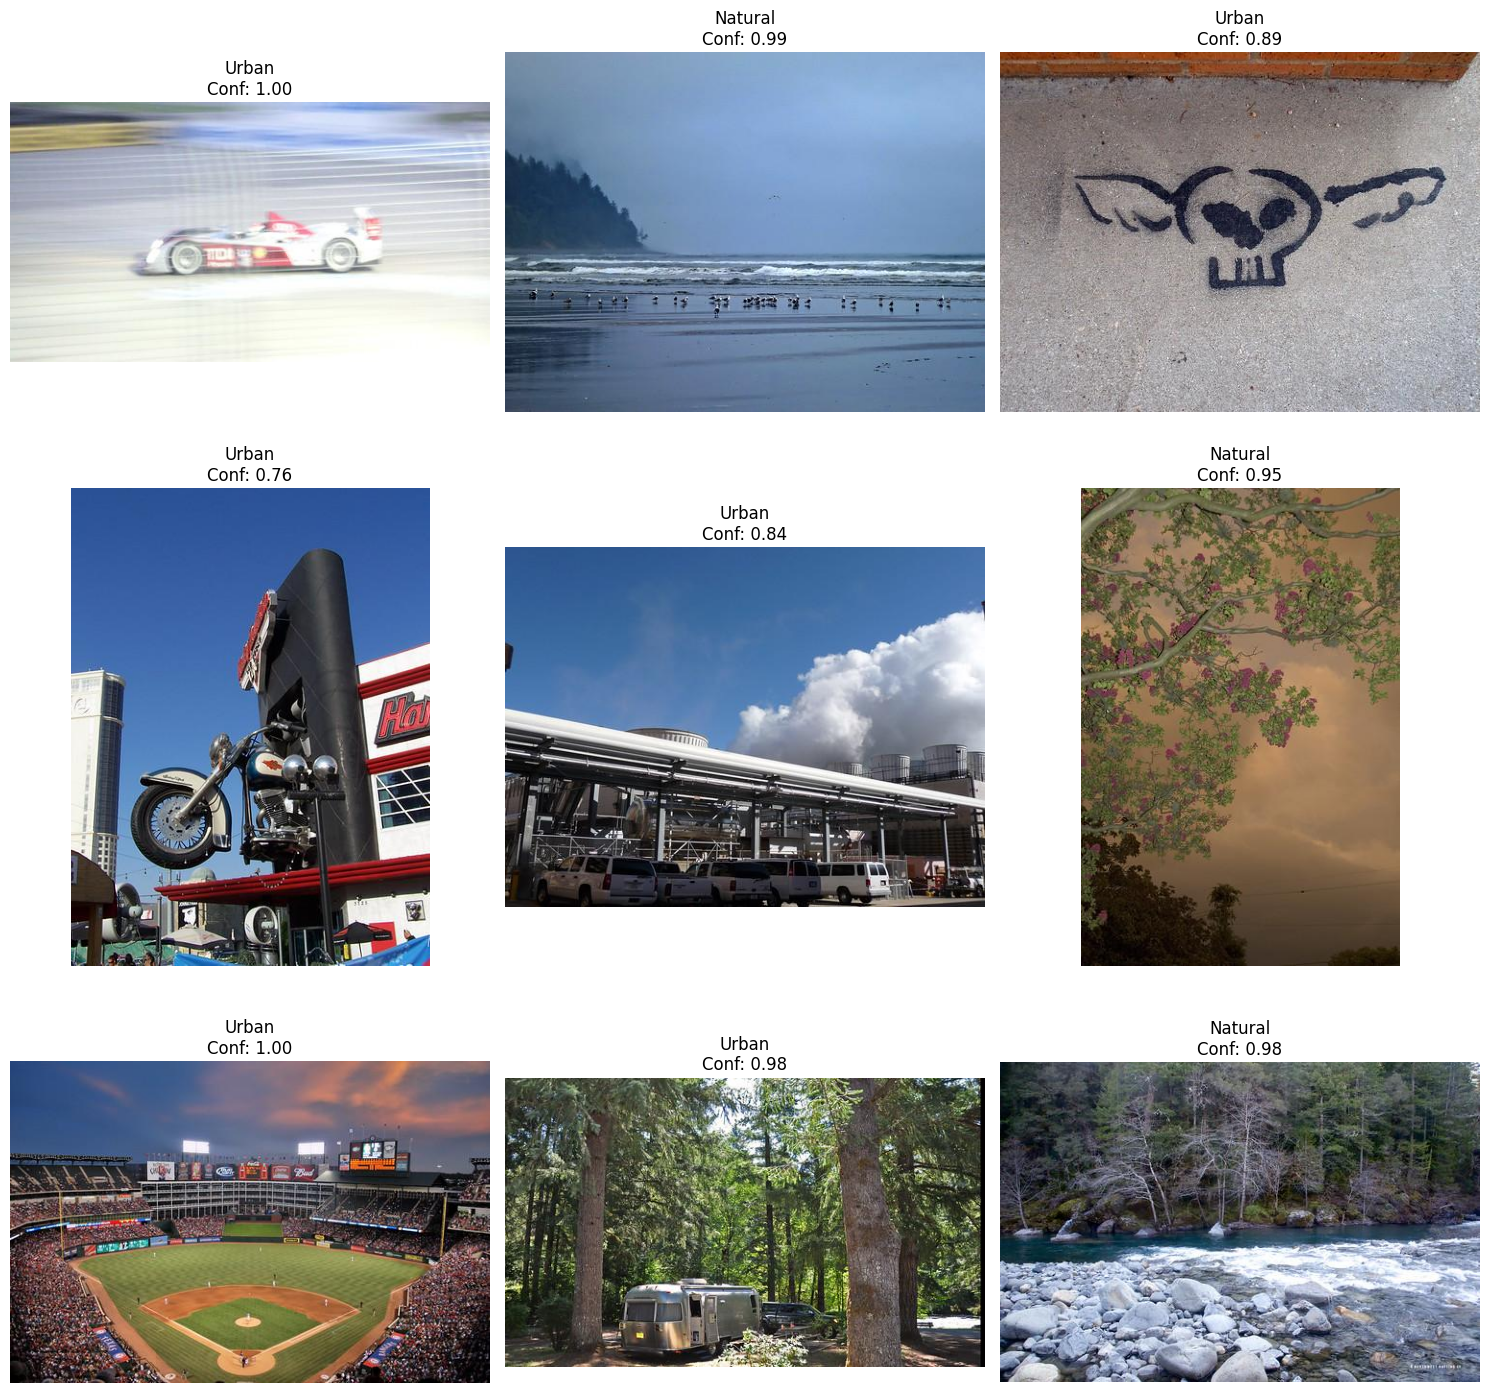

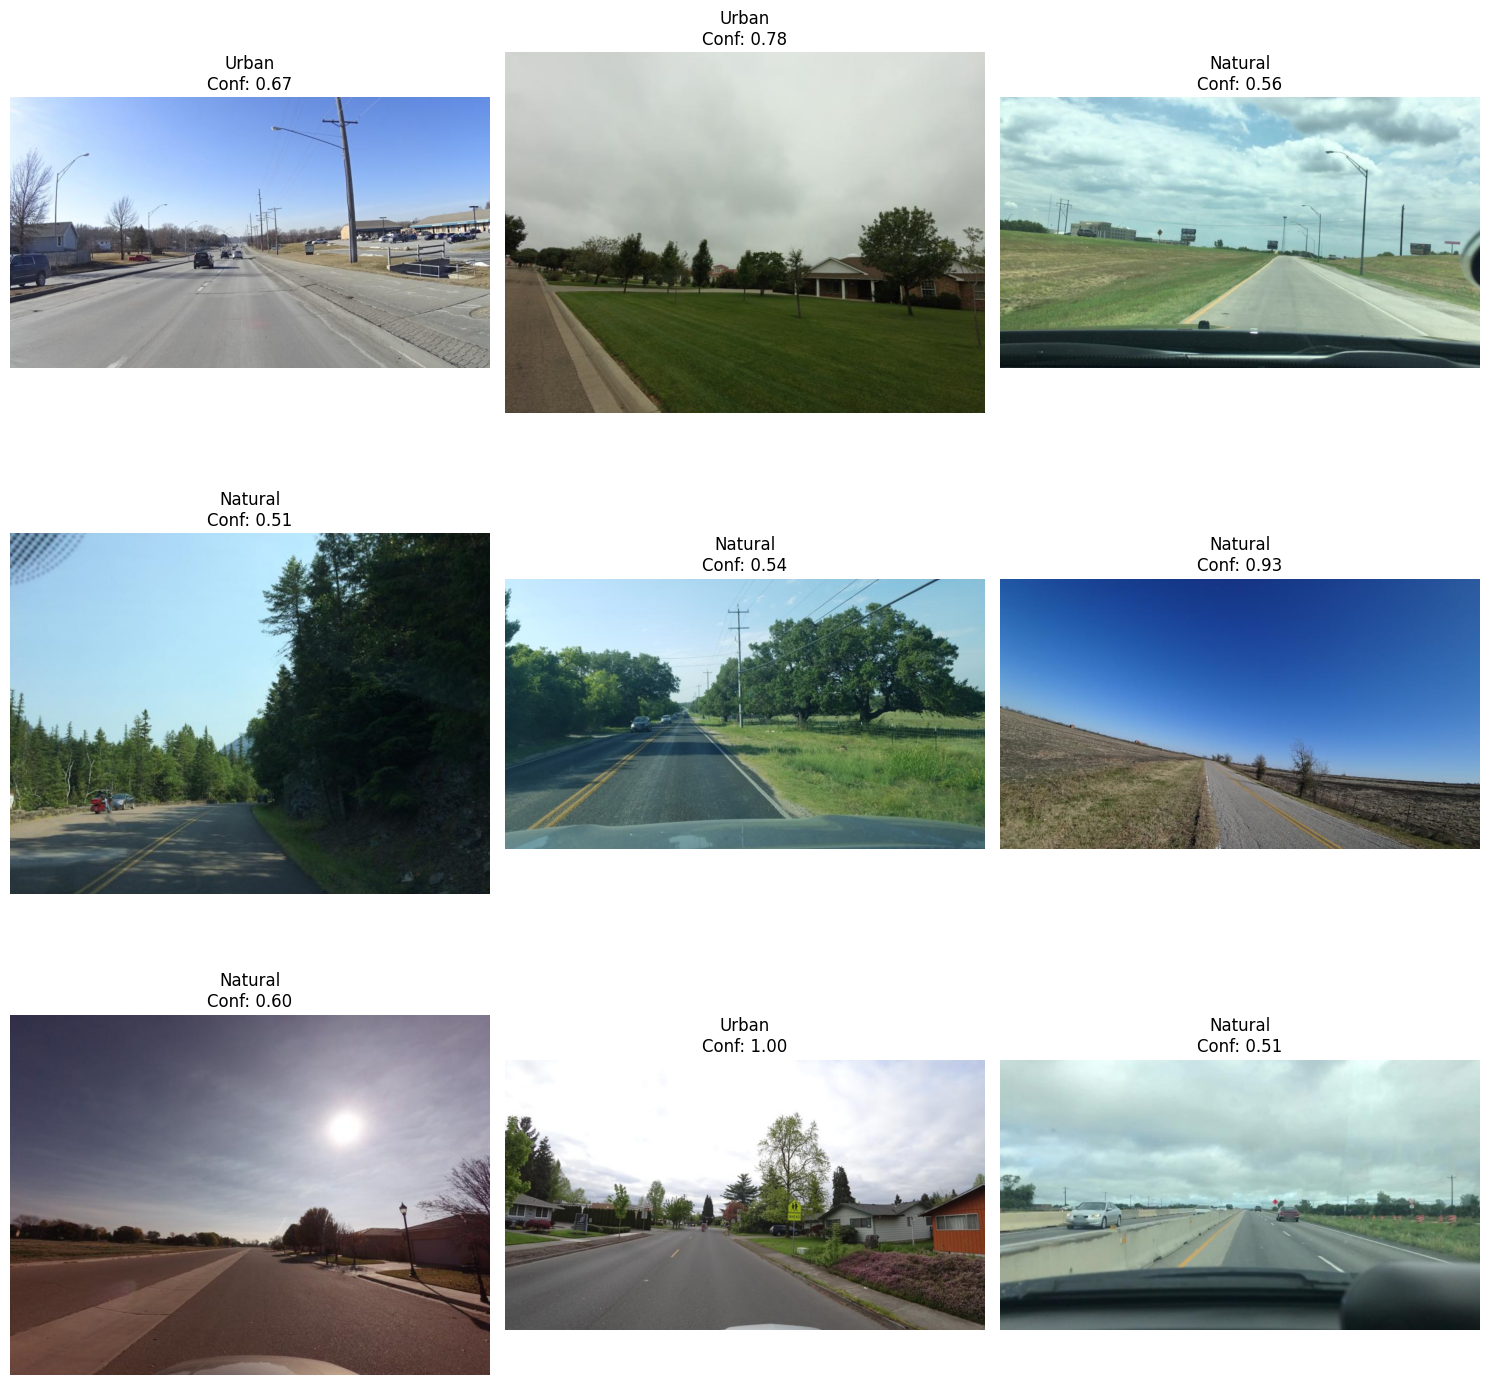

In [7]:
import matplotlib.pyplot as plt
for cfg in selected_configs:
    df_results = results_by_dataset[cfg.name].df_results
    OUTPUT_DIR = cfg.output_dir
    if len(df_results) > 0:
        # Show some sample images
        n_samples = min(9, len(df_results))
        sample_results = df_results.sample(n=n_samples)
        
        fig, axes = plt.subplots(3, 3, figsize=(15, 15))
        axes = axes.flatten()
        
        for idx, (_, row) in enumerate(sample_results.iterrows()):
            if idx >= 9:
                break
            
            # Try direct path first
            img_id = str(row['id']).replace(".jpg", "")
            img_path = OUTPUT_DIR / f"{img_id}.jpg"
            
            # If not found, search in nested folders
            if not img_path.exists():
                matching_files = list(OUTPUT_DIR.glob(f"**/{img_id}.jpg"))
                if matching_files:
                    img_path = matching_files[0]
            
            if img_path.exists():
                img = Image.open(img_path)
                axes[idx].imshow(img)
                axes[idx].set_title(f"{row['predicted_label']}\nConf: {row['confidence']:.2f}")
                axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No images to display.")